tutorial from https://docs.opencv.org/3.4/d8/d19/tutorial_stitcher.html
- [opencv docs](https://docs.opencv.org/4.13.0/)
- [opencv python tutorials](https://docs.opencv.org/4.13.0/d6/d00/tutorial_py_root.html)
- [opencv docs - autogenerated python API docs](https://ethanc8.github.io/opencv-python-docs/cv2.html) unofficial/community-created

In [1]:
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np

cv2.__version__

'4.13.0'

# Low Level Panorama

- we load the two images with OpenCV.
- always keep in mind the image format. OpenCV uses a BGR format, so we need to convert BGR -> RGB before plotting.

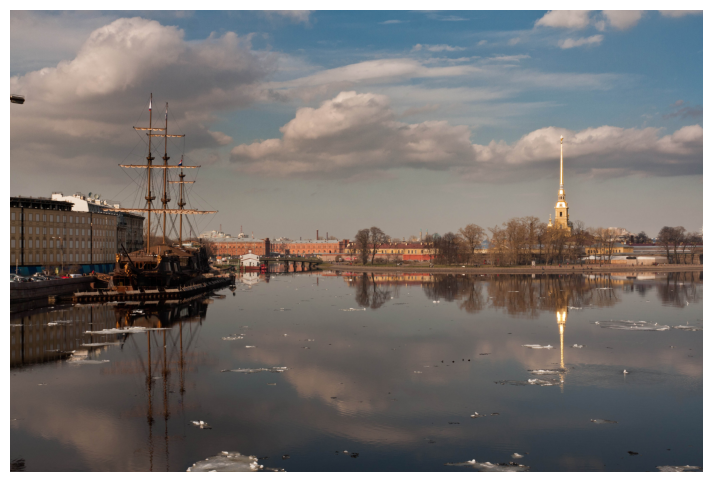

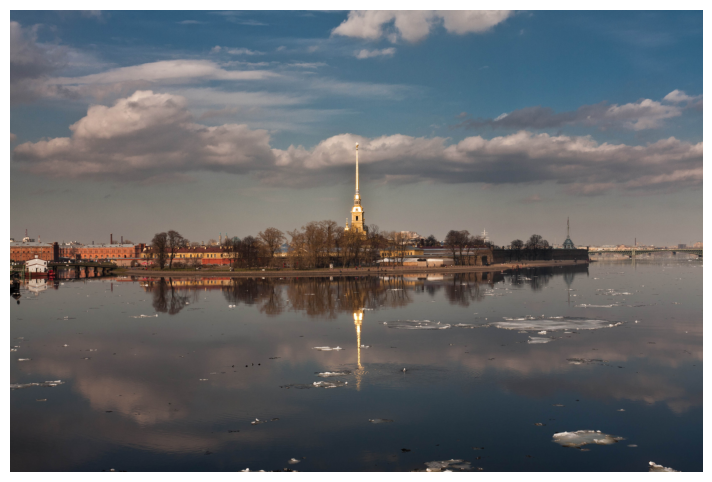

In [2]:
def to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def show(img, title=None, figsize=(10, 6), cmap=None):
    plt.figure(figsize=figsize)

    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or "gray")
    else:
        plt.imshow(to_rgb(img))

    if title:
        plt.title(title)

    plt.axis("off")
    plt.show()


img1 = cv2.imread("data/boat1.jpg")
img2 = cv2.imread("data/boat2.jpg")

show(img1)
show(img2)

## SIFT keypoints
next, we find SIFT keypoints.

In [3]:
def detect_and_match(img1, img2, ratio=0.75):
    # OpenCV SIFT uses a single channel, so we convert the input images to grayscale.
    # Notice that color is not that useful for matching, since the same keypoint in two images may have different colors due to lighting changes, shadows, etc.
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()

    # Detects keypoints and computes the descriptors for both images
    kps1, desc1 = sift.detectAndCompute(gray1, None)
    kps2, desc2 = sift.detectAndCompute(gray2, None)

    # Brute-force descriptor matcher.
    # For each descriptor in the first set, this matcher finds the closest descriptor in the second set by trying each one. 
    bf = cv2.BFMatcher(cv2.NORM_L2)
    # Finds the k best matches for each descriptor from a query set.
    knn = bf.knnMatch(desc1, desc2, k=2)

    # Lowe's ratio test: we only keep a match if the distance of the closest neighbor is less than `ratio` times the distance of the second closest neighbor.
    # The idea is that if the closest neighbor is much closer than the second closest, then it is a good match. Otherwise, it may be an ambiguous match and we discard it.
    matches = []
    for m, n in knn:
        if m.distance < ratio * n.distance:
            matches.append(m)

    # We extract the coordinates of the matched keypoints in both images.
    pts1 = np.float64([kps1[m.queryIdx].pt for m in matches])
    pts2 = np.float64([kps2[m.trainIdx].pt for m in matches])

    # pts* are the coordinates of the matched keypoints, 
    # kps* are the keypoint objects (which contain more information such as scale, orientation, etc.)
    # matches are the list of good matches that passed Lowe's ratio test.
    return pts1, pts2, kps1, kps2, matches

pts1, pts2, kps1, kps2, matches = detect_and_match(img1, img2)

print(f"matches: {len(matches)}")

matches: 3839


In [6]:
pts1[0]

array([  28.37364388, 2301.59082031])

In [14]:
kps1[0].angle, kps1[0].pt, kps1[0].response, kps1[0].size

(22.693023681640625,
 (2.353557586669922, 478.2621765136719),
 0.01953858695924282,
 1.9667209386825562)

In [11]:
matches[0].distance, matches[0].queryIdx, matches[0].trainIdx

(163.10426330566406, 79, 5091)

we can plot keypoints. SIFT provides a plot utility, but it doesn't work well with high resolution images such as ours.

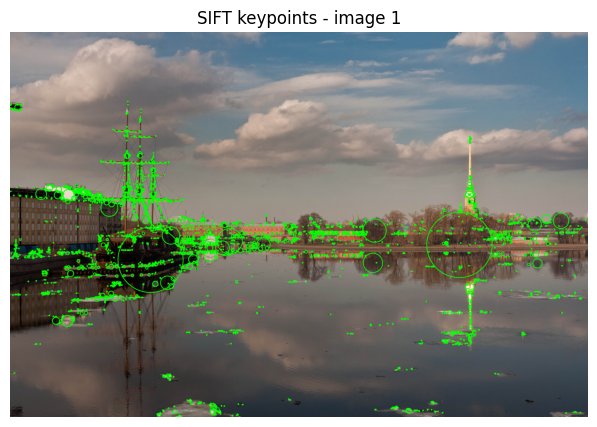

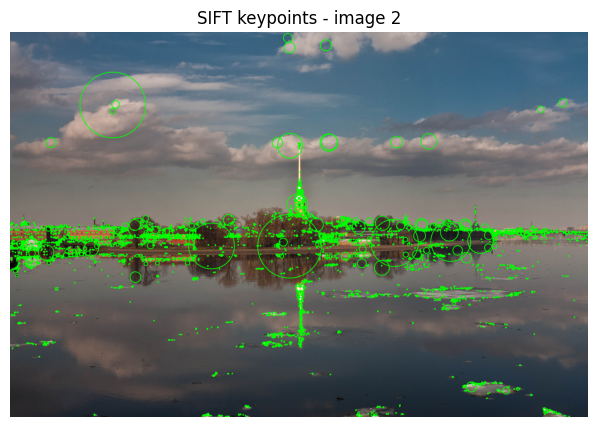

In [13]:
def draw_large_keypoints(img, keypoints,
                         radius_scale=0.5,
                         thickness=2,
                         max_points=None):
    # the default SIFT utility function cv2.drawKeypoints draws small circles around the keypoints, which are hard to see.
    out = img.copy()
    if max_points is not None:
        # we select the keypooints according to their strongest response
        keypoints = sorted(keypoints, key=lambda k: -k.response)[:max_points]

    for kp in keypoints:
        # The size of the keypoint is related to the scale at which it was detected. 
        # We can use it to draw a circle around the keypoint that reflects its scale.
        x, y = map(int, kp.pt)
        r = max(3, int(kp.size * radius_scale))
        cv2.circle(out, (x, y), r, (0, 255, 0), thickness, lineType=cv2.LINE_AA)
    return out


# cv2.drawKeypoints also exists, but it is not very customizable and does not allow us to draw thicker circles
kp_vis1 = draw_large_keypoints(img1, kps1, radius_scale=0.7, thickness=3, max_points=5000)
kp_vis2 = draw_large_keypoints(img2, kps2, radius_scale=0.7, thickness=3, max_points=5000)

show(kp_vis1, "SIFT keypoints - image 1", figsize=(9, 5))
show(kp_vis2, "SIFT keypoints - image 2", figsize=(9, 5))

## Keypoint Matching

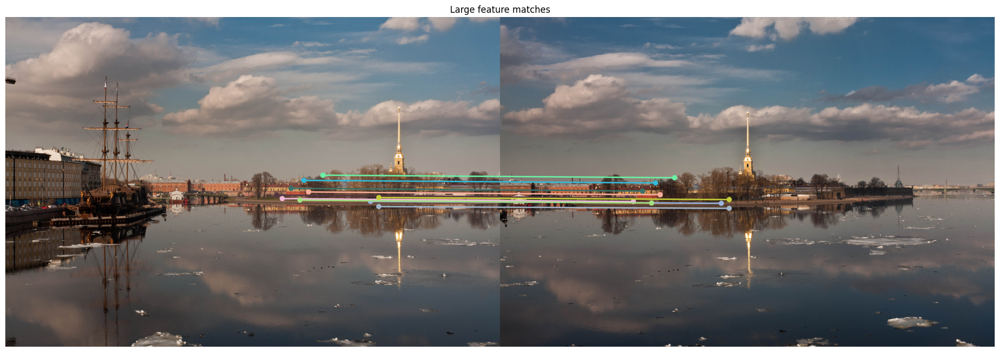

In [15]:
def draw_large_matches(img1, kps1,
                       img2, kps2,
                       matches, max_matches=80,
                       line_thickness=3, circle_radius=8):

    # create a canvas with both images side by side
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
    canvas[:h1, :w1] = img1
    canvas[:h2, w1:w1+w2] = img2

    # we sort the matches by distance (the smaller the distance, the better the match) and keep only the best `max_matches` matches.
    matches = sorted(matches, key=lambda m: m.distance)
    matches = matches[:max_matches]

    rng = np.random.default_rng(0)
    for m in matches:
        # for each match, we get the coordinates of the matched keypoints in both images.
        # we plot a line between the matched keypoints and a circle around each keypoint to highlight them.
        p1 = tuple(map(int, kps1[m.queryIdx].pt))
        p2 = tuple(map(int, kps2[m.trainIdx].pt))

        p2 = (p2[0] + w1, p2[1])

        color = tuple(int(x) for x in rng.integers(50, 255, size=3))

        cv2.line(canvas, p1, p2, color, line_thickness, lineType=cv2.LINE_AA)
        cv2.circle(canvas, p1, circle_radius, color, -1, lineType=cv2.LINE_AA)
        cv2.circle(canvas, p2, circle_radius, color, -1, lineType=cv2.LINE_AA)

    return canvas


match_vis = draw_large_matches(
    img1, kps1,
    img2, kps2,
    matches,
    max_matches=10,
    line_thickness=10,
    circle_radius=20,
)

show(match_vis, "Large feature matches", figsize=(24, 12))

## RANSAC
Now that we have matching points, we can find the model parameters. We use RANSAC for a robust estimate. The transformation is a homography.

We did not discuss the DLT in class yet, we are only interested in the code for RANSAC here.

In [16]:
def normalize_points(pts):
    """Not discussed in class."""
    mean = pts.mean(axis=0)
    std = pts.std(axis=0).mean()
    s = np.sqrt(2) / std
    T = np.array([
        [s, 0, -s * mean[0]],
        [0, s, -s * mean[1]],
        [0, 0, 1],
    ])
    pts_h = np.column_stack([pts, np.ones(len(pts))])
    pts_n = (T @ pts_h.T).T
    return pts_n[:, :2], T


def dlt_homography(src_pts, dst_pts):
    """Not discussed in class."""
    """Computes H such that dst ~ H @ src."""
    src_n, T_src = normalize_points(src_pts)
    dst_n, T_dst = normalize_points(dst_pts)

    A = []
    for (x, y), (u, v) in zip(src_n, dst_n):
        A.append([-x, -y, -1,  0,  0,  0, u*x, u*y, u])
        A.append([ 0,  0,  0, -x, -y, -1, v*x, v*y, v])
    A = np.asarray(A)

    _, _, Vt = np.linalg.svd(A)
    H_n = Vt[-1].reshape(3, 3)
    H = np.linalg.inv(T_dst) @ H_n @ T_src
    H /= H[2, 2]
    return H


def reprojection_errors(H, src_pts, dst_pts):
    """Not discussed in class."""
    src_h = np.column_stack([src_pts, np.ones(len(src_pts))])
    pred_h = (H @ src_h.T).T
    pred = pred_h[:, :2] / pred_h[:, 2:3]
    return np.linalg.norm(pred - dst_pts, axis=1)


def ransac_homography(src_pts, dst_pts, num_iters=3000, threshold=4.0):
    best_H = None
    best_inliers = None
    best_count = 0

    n = len(src_pts)
    if n < 4:
        raise ValueError("Need at least 4 matches.")

    for _ in range(num_iters):        
        # we randomly select 4 correspondences to compute a candidate homography.
        # We need at least 4 correspondences to compute a homography, since a homography has 8 degrees of freedom 
        # (it is a 3x3 matrix defined up to scale) and each correspondence provides 2 equations.
        idx = np.random.choice(n, 4, replace=False)

        try:
            # we compute the homography H using the DLT algorithm on the selected correspondences.
            H = dlt_homography(src_pts[idx], dst_pts[idx])
        except np.linalg.LinAlgError:
            # if the selected points are collinear, the DLT algorithm will fail to compute a valid homography. 
            # In that case, we skip this iteration and try again.
            continue

        # compute instance-wise reprojection errors for all correspondences using the candidate homography H.
        errs = reprojection_errors(H, src_pts, dst_pts)
        # inliers are the correspondences whose reprojection error is less than the specified threshold.
        inliers = errs < threshold
        count = np.sum(inliers)

        # we want to find the homography that has the largest number of inliers, so we keep track of the best one found so far.
        if count > best_count:
            best_count = count
            best_inliers = inliers
            best_H = H

    if best_H is None:
        raise RuntimeError("RANSAC failed.")

    # Refit using all inliers.
    H_refined = dlt_homography(src_pts[best_inliers], dst_pts[best_inliers])

    return H_refined, best_inliers


# We want H such that img2 points map into img1.
H, inliers = ransac_homography(pts2, pts1)

print(f"inliers: {inliers.sum()} / {len(inliers)}")

inliers: 3258 / 3839


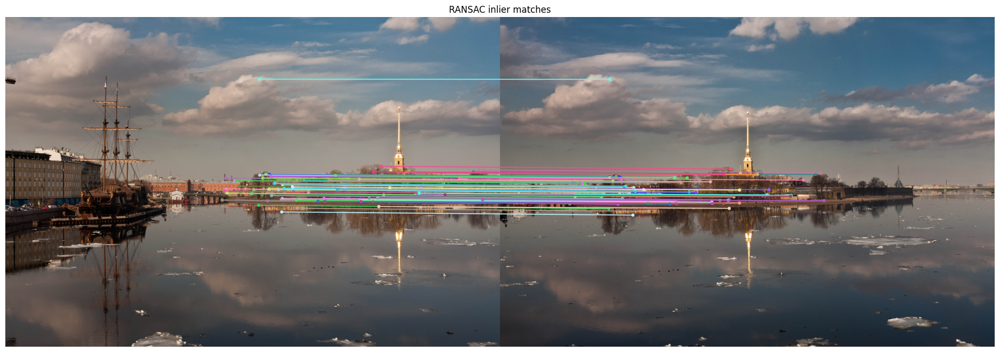

In [17]:
inlier_matches = [m for m, keep in zip(matches, inliers) if keep]
inlier_vis = draw_large_matches(img1, kps1, img2, kps2, inlier_matches, max_matches=80, line_thickness=5, circle_radius=12)
show(inlier_vis, "RANSAC inlier matches", figsize=(24, 12))

finally, we stitch the two images. We have not discussed the details of how to do this in class.

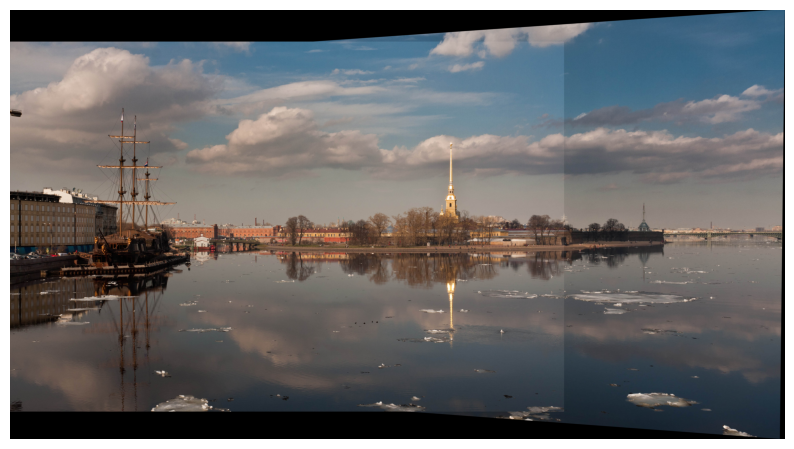

In [18]:
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]

corners_img1 = np.float64([
    [0, 0],
    [w1, 0],
    [w1, h1],
    [0, h1],
])

corners_img2 = np.float64([
    [0, 0],
    [w2, 0],
    [w2, h2],
    [0, h2],
])

# We warp the corners of img2 using the estimated homography H to find out where they map in the coordinate system of img1. 
# This will help us determine the size of the canvas needed to create the panorama.
corners_img2_h = np.column_stack([corners_img2, np.ones(4)])
warped_corners_img2_h = (H @ corners_img2_h.T).T
warped_corners_img2 = warped_corners_img2_h[:, :2] / warped_corners_img2_h[:, 2:3]
all_corners = np.vstack([corners_img1, warped_corners_img2])

# We compute the bounding box of all corners to determine the size of the panorama canvas.
xmin, ymin = np.floor(all_corners.min(axis=0)).astype(int)
xmax, ymax = np.ceil(all_corners.max(axis=0)).astype(int)

# We want to create a canvas that can fit both img1 and the warped img2. Since the warped img2 may have negative coordinates (if it extends to the left or above img1), we need to translate the coordinate system so that all coordinates are positive. We compute the translation needed to move the top-left corner of the bounding box to the origin (0, 0).
tx, ty = -xmin, -ymin
T = np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1],
])

# The size of the panorama is determined by the bounding box we computed, which can fit both img1 and the warped img2.
pano_w = xmax - xmin
pano_h = ymax - ymin

# We warp img2 using the homography H and the translation T to align it with img1 in the panorama coordinate system. 
# The resulting warped image will be placed on a canvas of size (pano_w, pano_h).
warped_img2 = cv2.warpPerspective(img2, T @ H, (pano_w, pano_h))

panorama = warped_img2.copy()

# Paste img1 into translated canvas.
panorama[ty:ty + h1, tx:tx + w1] = img1

show(panorama)

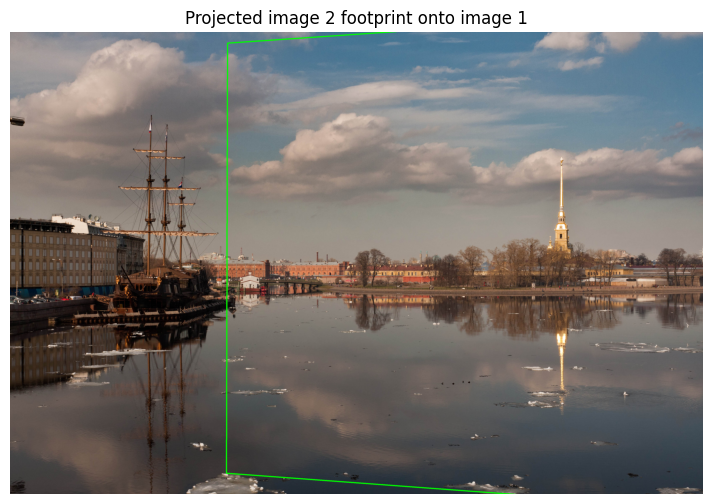

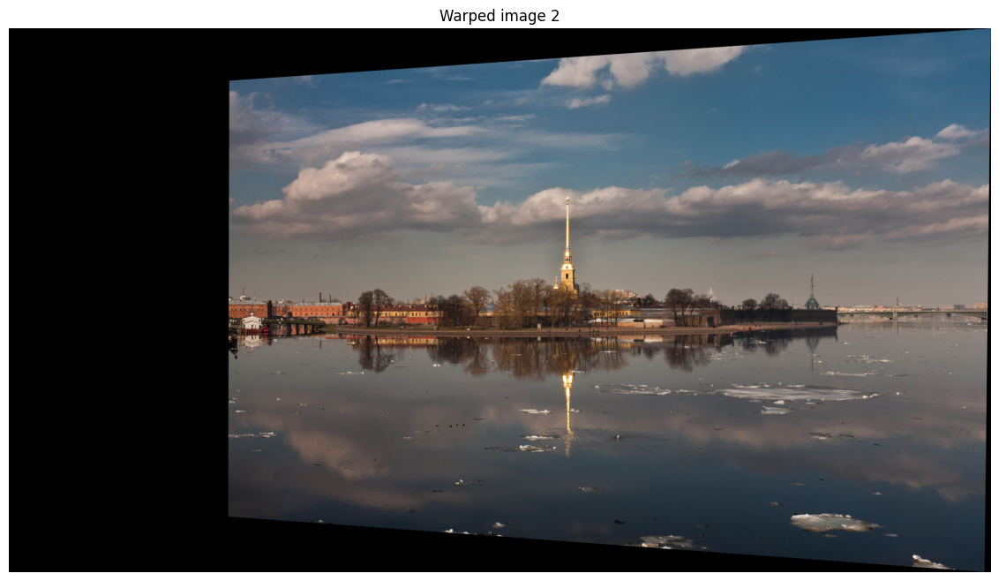

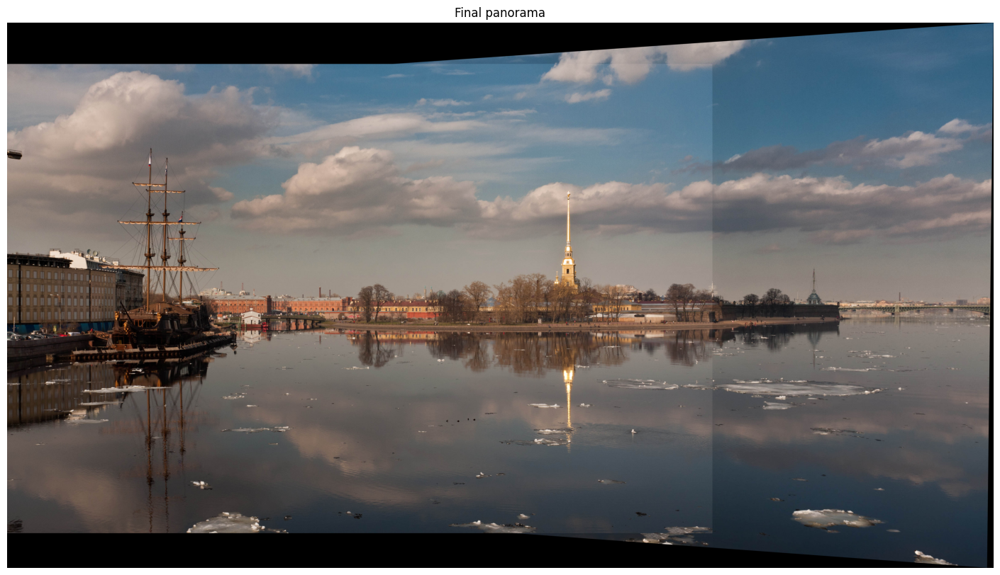

In [19]:
# Visualize projected corners
h2, w2 = img2.shape[:2]
corners = np.float32([
    [0, 0],
    [w2, 0],
    [w2, h2],
    [0, h2],
]).reshape(-1, 1, 2)

proj = cv2.perspectiveTransform(corners, H)

overlay = img1.copy()
cv2.polylines(
    overlay,
    [np.int32(proj)],
    isClosed=True,
    color=(0, 255, 0),
    thickness=5,
)
show(overlay, "Projected image 2 footprint onto image 1")

# Warp + panorama
h1, w1 = img1.shape[:2]
corners_img1 = np.float32([
    [0, 0],
    [w1, 0],
    [w1, h1],
    [0, h1],
])
corners_img2 = np.float32([
    [0, 0],
    [w2, 0],
    [w2, h2],
    [0, h2],
]).reshape(-1, 1, 2)

warped_corners_img2 = cv2.perspectiveTransform(corners_img2, H).reshape(-1, 2)
all_pts = np.vstack([corners_img1, warped_corners_img2])

xmin, ymin = np.floor(all_pts.min(axis=0)).astype(int)
xmax, ymax = np.ceil(all_pts.max(axis=0)).astype(int)
tx, ty = -xmin, -ymin
T = np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1],
])

panorama_width = xmax - xmin
panorama_height = ymax - ymin
warped_img2 = cv2.warpPerspective(
    img2,
    T @ H,
    (panorama_width, panorama_height)
)
show(warped_img2, "Warped image 2", figsize=(16, 8))

# ------------------------------------------------------------
# Composite panorama
# ------------------------------------------------------------
panorama = warped_img2.copy()
panorama[ty:ty + h1, tx:tx + w1] = img1
show(panorama, "Final panorama", figsize=(20, 10))

# Putting it all together

matches: 3839
inliers: 3260 / 3839


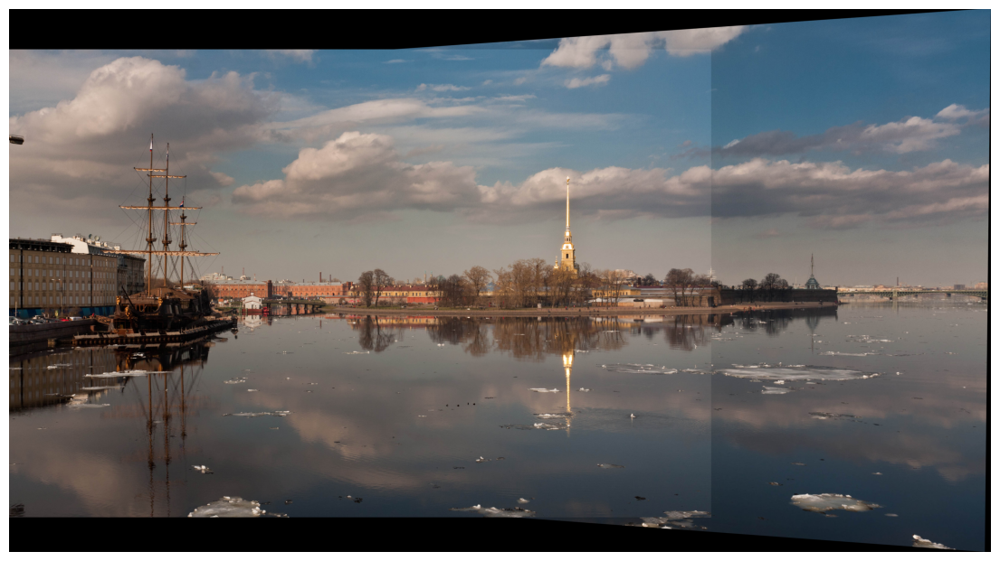

In [20]:
def to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def show(img, figsize=(14, 8)):
    plt.figure(figsize=figsize)
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(to_rgb(img))
    plt.axis("off")
    plt.show()


def detect_and_match(img1, img2, ratio=0.75):
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()

    kps1, desc1 = sift.detectAndCompute(gray1, None)
    kps2, desc2 = sift.detectAndCompute(gray2, None)

    bf = cv2.BFMatcher(cv2.NORM_L2)
    knn = bf.knnMatch(desc1, desc2, k=2)

    matches = []
    for m, n in knn:
        if m.distance < ratio * n.distance:
            matches.append(m)

    pts1 = np.float64([kps1[m.queryIdx].pt for m in matches])
    pts2 = np.float64([kps2[m.trainIdx].pt for m in matches])

    return pts1, pts2, kps1, kps2, matches


def normalize_points(pts):
    mean = pts.mean(axis=0)
    std = pts.std(axis=0).mean()

    s = np.sqrt(2) / std

    T = np.array([
        [s, 0, -s * mean[0]],
        [0, s, -s * mean[1]],
        [0, 0, 1],
    ])

    pts_h = np.column_stack([pts, np.ones(len(pts))])
    pts_n = (T @ pts_h.T).T

    return pts_n[:, :2], T


def dlt_homography(src_pts, dst_pts):
    """
    Computes H such that dst ~ H @ src.
    """
    src_n, T_src = normalize_points(src_pts)
    dst_n, T_dst = normalize_points(dst_pts)

    A = []

    for (x, y), (u, v) in zip(src_n, dst_n):
        A.append([-x, -y, -1,  0,  0,  0, u*x, u*y, u])
        A.append([ 0,  0,  0, -x, -y, -1, v*x, v*y, v])

    A = np.asarray(A)

    _, _, Vt = np.linalg.svd(A)
    H_n = Vt[-1].reshape(3, 3)

    H = np.linalg.inv(T_dst) @ H_n @ T_src
    H /= H[2, 2]

    return H


def reprojection_errors(H, src_pts, dst_pts):
    src_h = np.column_stack([src_pts, np.ones(len(src_pts))])
    pred_h = (H @ src_h.T).T
    pred = pred_h[:, :2] / pred_h[:, 2:3]

    return np.linalg.norm(pred - dst_pts, axis=1)


def ransac_homography(src_pts, dst_pts, num_iters=3000, threshold=4.0):
    best_H = None
    best_inliers = None
    best_count = 0

    n = len(src_pts)

    if n < 4:
        raise ValueError("Need at least 4 matches.")

    for _ in range(num_iters):
        idx = np.random.choice(n, 4, replace=False)

        try:
            H = dlt_homography(src_pts[idx], dst_pts[idx])
        except np.linalg.LinAlgError:
            continue

        errs = reprojection_errors(H, src_pts, dst_pts)
        inliers = errs < threshold
        count = np.sum(inliers)

        if count > best_count:
            best_count = count
            best_inliers = inliers
            best_H = H

    if best_H is None:
        raise RuntimeError("RANSAC failed.")

    # Refit using all inliers.
    H_refined = dlt_homography(src_pts[best_inliers], dst_pts[best_inliers])

    return H_refined, best_inliers


def stitch_two_images(img1, img2):
    """
    Returns panorama. Warps img2 into img1 coordinates.

    H maps img2 -> img1.
    """
    pts1, pts2, kps1, kps2, matches = detect_and_match(img1, img2)

    print(f"matches: {len(matches)}")

    # We want H such that img2 points map into img1.
    H, inliers = ransac_homography(pts2, pts1)

    print(f"inliers: {inliers.sum()} / {len(inliers)}")

    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    corners_img1 = np.float64([
        [0, 0],
        [w1, 0],
        [w1, h1],
        [0, h1],
    ])

    corners_img2 = np.float64([
        [0, 0],
        [w2, 0],
        [w2, h2],
        [0, h2],
    ])

    corners_img2_h = np.column_stack([corners_img2, np.ones(4)])
    warped_corners_img2_h = (H @ corners_img2_h.T).T
    warped_corners_img2 = warped_corners_img2_h[:, :2] / warped_corners_img2_h[:, 2:3]

    all_corners = np.vstack([corners_img1, warped_corners_img2])

    xmin, ymin = np.floor(all_corners.min(axis=0)).astype(int)
    xmax, ymax = np.ceil(all_corners.max(axis=0)).astype(int)

    tx, ty = -xmin, -ymin

    T = np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1],
    ])

    pano_w = xmax - xmin
    pano_h = ymax - ymin

    warped_img2 = cv2.warpPerspective(img2, T @ H, (pano_w, pano_h))

    panorama = warped_img2.copy()

    # Paste img1 into translated canvas.
    panorama[ty:ty + h1, tx:tx + w1] = img1

    return panorama, H, inliers, matches, kps1, kps2


# Example usage
img1 = cv2.imread("data/boat1.jpg")
img2 = cv2.imread("data/boat2.jpg")

pano, H, inliers, matches, kps1, kps2 = stitch_two_images(img1, img2)

show(pano)

# High-Level API - OpenCV Stitcher

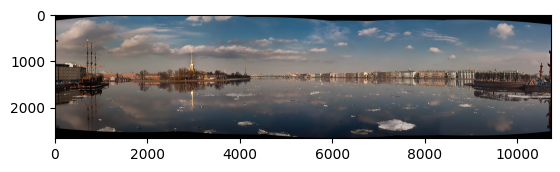

In [21]:
def split_image_d3(img):
    h, w = img.shape[:2]
    half_w = w // 2

    return [
        img[:, 0:half_w].copy(),
        img[:, w // 3 : w // 3 + half_w].copy(),
        img[:, w // 2 : w // 2 + half_w].copy(),
    ]


def main(images, d3, mode):
    imgs = []
    for path in images:
        img = cv2.imread(path)
        if img is None:
            print(f"Can't read image '{path}'", file=sys.stderr)
            return 1

        if d3:
            imgs.extend(split_image_d3(img))
        else:
            imgs.append(img)

    mode = cv2.Stitcher_PANORAMA if mode == "panorama" else cv2.Stitcher_SCANS
    stitcher = cv2.Stitcher_create(mode)
    status, pano = stitcher.stitch(imgs)

    if status != cv2.Stitcher_OK:
        print(f"Can't stitch images, error code = {status}", file=sys.stderr)
        return 1

    return pano


args = {
    "d3": False,  # help="Internally creates three chunks of each image to increase stitching success.",
    "mode": "panorama",  # help="Stitcher mode. Default: panorama. choices=("panorama", "scans")
    "images": ["data/boat1.jpg", "data/boat2.jpg", "data/boat3.jpg", "data/boat4.jpg", "data/boat5.jpg", "data/boat6.jpg"],  # help="Input image paths."
}

pano = main(**args)
# ok = cv2.imwrite(outfile, pano)  # <-- if you want to save the output
plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))

# Exercises
- take a bit of time to explore OpenCV's doc, especially SIFT and the Stitcher class.
- we only have the ratio test as a filter for bad matches. You can add the mutual nearest neighbors
- Test the high-level OpenCV Stitcher with the Affine model
  - [C++ tutorial](https://github.com/opencv/opencv_extra/tree/5.x/testdata/stitching)
  - [OpenCV extra samples](https://github.com/opencv/opencv_extra/tree/5.x/testdata/stitching) newspaper and budapest are the relevant samples. Boat is the one we used above.
- you can experiment with a different descriptor. OpenCV has [python tutorials](https://docs.opencv.org/4.13.0/db/d27/tutorial_py_table_of_contents_feature2d.html) for SURF, BRIEF, ORB. You have to change how we extract the keypoints and features but also how we measure the distance (e.g. a binary descriptor like ORB requires Hamming distance NORM_HAMMING2) 